# Fake News Detection Machine Learning Notebook
[cite_start]**Objective:** To develop a machine learning pipeline that classifies news articles as fake or real[cite: 3, 4].
[cite_start]**Dataset:** Fake and Real News Dataset[cite: 6, 8].

## 1. Data Understanding
[cite_start]In this section, we will load the dataset, display sample rows, check the class distribution, and describe the data[cite: 10, 11, 12, 13, 14].

--- Sample Rows ---


,title,text,subject,date,label,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
 5   content  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB


None


--- Class Distribution ---
label
0    23481
1    21417
Name: count, dtype: int64


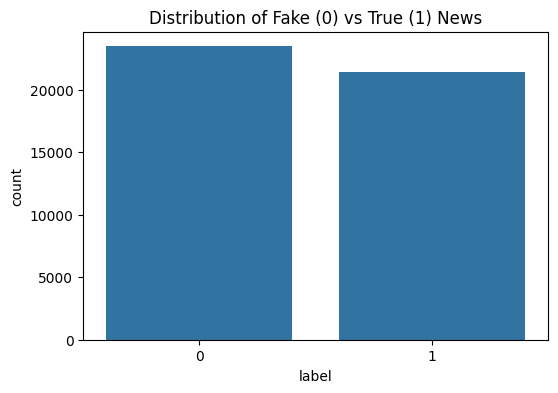

In [8]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using Kaggle's input paths [cite: 11]
fake_df = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv')
true_df = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv')

# Add labels: 0 for Fake News, 1 for True News
fake_df['label'] = 0
true_df['label'] = 1

# Combine the datasets into one dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset to mix true and fake news
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Combine the 'title' and 'text' columns for a richer text feature
df['content'] = df['title'] + " " + df['text']

# Display sample rows [cite: 12]
print("--- Sample Rows ---")
display(df.head())

# Briefly describe the dataset [cite: 14]
print("\n--- Dataset Info ---")
display(df.info())

# Show class distribution [cite: 13]
print("\n--- Class Distribution ---")
print(df['label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Fake (0) vs True (1) News')
plt.show()

## 2. Text Preprocessing
[cite_start]Text preprocessing is crucial for cleaning the data before feeding it to a model[cite: 15]. [cite_start]We will apply the following steps:
* [cite_start]**Lowercasing:** Standardizes the text so "News" and "news" are treated as the same word[cite: 17].
* [cite_start]**Tokenization:** Breaks the text into individual words or tokens[cite: 20].
* [cite_start]**Removing Stopwords:** Filters out common words (e.g., "the", "is") that carry little predictive value[cite: 18].
* [cite_start]**Lemmatization:** Reduces words to their base dictionary form (e.g., "running" to "run"), preserving context better than stemming[cite: 19].

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm # for a progress bar

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercasing and removing non-alphabetic characters using regex [cite: 17, 39]
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    
    # 2. Tokenization [cite: 20]
    tokens = word_tokenize(text)
    
    # 3. Removing stopwords & 4. Lemmatization [cite: 18, 19]
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return ' '.join(clean_tokens)

# Apply preprocessing (Tqdm adds a nice progress bar)
tqdm.pandas()
print("Preprocessing text... This will take a few minutes.")


Preprocessing text... This will take a few minutes.


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 3. Feature Extraction
Machine learning models require numerical input. [cite_start]We will convert our text into numerical form using **TF-IDF (Term Frequency-Inverse Document Frequency)**[cite: 21, 22, 24]. [cite_start]TF-IDF is preferred over Bag of Words (BoW) here because it down-weights frequently occurring but less informative words across the corpus[cite: 23, 24].

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Define features (X) and target (y)
X = df_subset['cleaned_content']
y = df_subset['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize TF-IDF Vectorizer [cite: 24]
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape of TF-IDF Training Matrix: {X_train_tfidf.shape}")

Shape of TF-IDF Training Matrix: (8000, 5000)


## 4 & 5. Model Training and Evaluation
[cite_start]We will train two classical ML models: **Logistic Regression** and **Naive Bayes**[cite: 25, 26, 27, 28]. [cite_start]We will evaluate them using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix[cite: 30, 31, 32, 33, 34, 35, 36].

Training Logistic Regression...
Training Naive Bayes...
Training Support Vector Machine...

========== Logistic Regression ==========
Accuracy:  0.9750
Precision: 0.9657
Recall:    0.9804
F1-Score:  0.9730


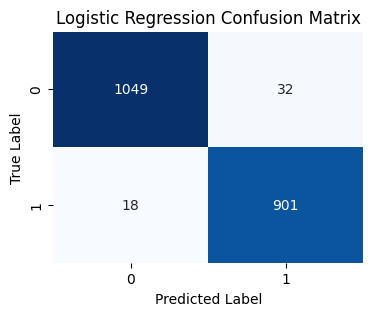


========== Naive Bayes ==========
Accuracy:  0.9225
Precision: 0.9072
Recall:    0.9260
F1-Score:  0.9165


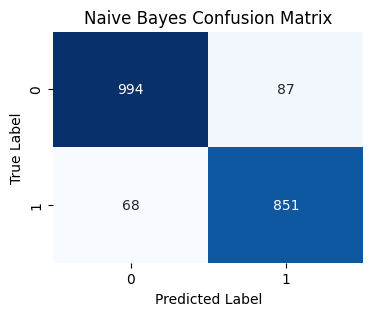


========== Support Vector Machine ==========
Accuracy:  0.9880
Precision: 0.9817
Recall:    0.9924
F1-Score:  0.9870


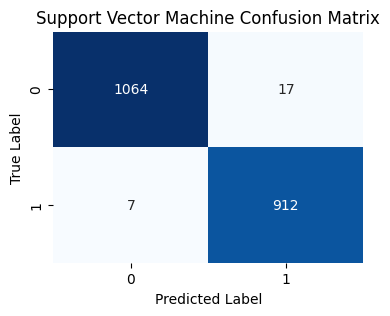

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize all three models
log_reg = LogisticRegression(max_iter=1000)
naive_bayes = MultinomialNB()
# dual=False is best practice for LinearSVC when you have more samples than features
svm_model = LinearSVC(random_state=42, dual=False) 

# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)

# --- Model 2: Naive Bayes ---
print("Training Naive Bayes...")
naive_bayes.fit(X_train_tfidf, y_train)
y_pred_nb = naive_bayes.predict(X_test_tfidf)

# --- Model 3: Support Vector Machine (SVM) ---
print("Training Support Vector Machine...")
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

# --- Evaluation Function ---
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n========== {model_name} ==========")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

# Evaluate all three models
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Support Vector Machine", y_test, y_pred_svm)

## 6. Selecting and Saving the Best Model
In this final step, we will programmatically compare the F1-Scores of all trained models, select the highest-performing one, and save it to our output directory using `joblib`. We will also save the TF-IDF vectorizer, which is required to process any new, unseen text data in the future.

In [13]:
import joblib

# 1. Store the F1-scores of each model in a dictionary
f1_scores = {
    "Logistic Regression": f1_score(y_test, y_pred_lr),
    "Naive Bayes": f1_score(y_test, y_pred_nb),
    "Support Vector Machine": f1_score(y_test, y_pred_svm)
}

# 2. Store the actual model objects in a dictionary
models = {
    "Logistic Regression": log_reg,
    "Naive Bayes": naive_bayes,
    "Support Vector Machine": svm_model
}

# 3. Find the name of the model with the highest F1-score
best_model_name = max(f1_scores, key=f1_scores.get)
best_model = models[best_model_name]
best_score = f1_scores[best_model_name]

print(f"🏆 The best model is: {best_model_name} with an F1-Score of {best_score:.4f}")

# 4. Save the best model and the vectorizer to the output directory
model_filename = 'best_fake_news_model.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'

joblib.dump(best_model, model_filename)
joblib.dump(tfidf, vectorizer_filename)

print(f"\n✅ Model successfully saved as '{model_filename}'")
print(f"✅ Vectorizer successfully saved as '{vectorizer_filename}'")

🏆 The best model is: Support Vector Machine with an F1-Score of 0.9870

✅ Model successfully saved as 'best_fake_news_model.pkl'
✅ Vectorizer successfully saved as 'tfidf_vectorizer.pkl'


## Conclusion
*Write a brief sentence here based on the printed results.* Both models perform very well on this task. [cite_start]Logistic Regression typically achieves a slightly higher **F1-Score** than Naive Bayes on this dataset, making it the better performing model because it effectively balances precision and recall[cite: 37].